# EDA de Features Transformadas: Enfermedades Cardiovasculares

## 1. Introduccion

Este notebook se centra en la visualizacion de los datos ya transformados por el pipeline `build_features.py`.
Se usan los conjuntos procesados para revisar calidad, distribuciones y relaciones con la variable objetivo.

### 1.1 Objetivos

1. Verificar la consistencia de los datos transformados.
2. Revisar el balance de clases por split.
3. Explorar distribuciones de features derivadas.
4. Analizar relaciones con la variable objetivo.
5. Identificar correlaciones relevantes entre features.

## 2. Importacion de bibliotecas

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Configuración
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

# Ruta de los datos procesados
DATA_DIR = '../data/processed/model_inputs'

## 3. Carga y Exploración Inicial de Datos

In [2]:
def load_split(split_name):
    x_path = os.path.join(DATA_DIR, f'X_{split_name}.csv')
    y_path = os.path.join(DATA_DIR, f'y_{split_name}.csv')
    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path).iloc[:, 0]
    return X, y

X_train, y_train = load_split('train')
X_val, y_val = load_split('val')
X_test, y_test = load_split('test')

print(f"Dimensiones del dataset: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} registros × {X_train.shape[1]} variables")
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f'Total features: {X_train.shape[1]}')
X_train.head(10)

Dimensiones del dataset: 68525 registros × 28 variables
X_train: (55504, 28), y_train: (55504,)
X_val:   (6168, 28), y_val:   (6168,)
X_test:  (6853, 28), y_test:  (6853,)
Total features: 28


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,hipertension_nivel,imc_edad_interaction,presion_imc_interaction,colesterol_glucosa_interaction,lifestyle_score,risk_factor_count,edad_squared,imc_squared,log_ap_hi,col_gluc_ratio
0,-0.136252,1.0,0.909091,0.470588,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.109296,-0.108642,0.0,0.000000,0.0,-0.135959,-0.034885,0.000000,0.000000
1,-0.351373,0.0,0.363636,1.117647,-0.50,-1.0,1.0,0.0,0.0,0.0,...,-1.0,0.420068,0.162895,1.0,0.000000,1.0,-0.343488,0.952698,-0.563906,0.666667
2,-0.640468,1.0,1.636364,2.529412,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.476862,0.850864,0.0,0.000000,0.0,-0.608632,1.439533,0.000000,0.000000
3,0.417460,0.0,-0.181818,-0.882353,0.50,0.0,0.0,2.0,0.0,0.0,...,0.0,-0.395599,-0.564352,2.0,0.000000,0.0,0.438360,-0.694083,0.519103,-0.380952
4,0.023933,0.0,-0.454545,0.176471,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.377781,0.262030,0.0,0.000000,0.0,0.024243,0.487199,0.000000,0.000000
5,0.803100,0.0,0.000000,0.117647,0.50,0.0,2.0,0.0,0.0,0.0,...,0.0,0.601955,0.128304,2.0,0.000000,1.0,0.872516,0.132547,0.519103,1.333333
6,-0.386184,0.0,-0.545455,-0.470588,-1.00,0.0,0.0,0.0,1.0,0.0,...,0.0,-0.350688,-0.414020,0.0,2.333333,2.0,-0.376250,-0.158074,-1.181087,0.000000
7,-0.403318,0.0,1.363636,0.882353,-1.00,1.0,2.0,2.0,0.0,0.0,...,1.0,-0.186287,-0.023471,8.0,0.000000,2.0,-0.392291,0.079784,-1.181087,0.190476
8,-0.172695,0.0,-0.363636,0.176471,-0.50,0.0,1.0,2.0,0.0,0.0,...,0.0,0.202785,0.099002,5.0,0.000000,2.0,-0.171730,0.424503,-0.563906,-0.095238
9,0.758227,0.0,-1.181818,-0.235294,1.75,-0.9,0.0,0.0,0.0,0.0,...,1.0,0.889350,0.486483,0.0,0.000000,0.0,0.820555,0.510773,1.660891,0.000000


In [3]:
X_all = pd.concat([X_train, X_val, X_test], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)

data_all = X_all.copy()
data_all['cardio'] = y_all.values
data_all['split'] = (
    ['train'] * len(X_train) +
    ['val'] * len(X_val) +
    ['test'] * len(X_test)
)

# Información del dataset combinado
print('Información del dataset combinado:')
data_all.info()

Información del dataset combinado:
<class 'pandas.core.frame.DataFrame'>
Index: 68525 entries, 0 to 6852
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             68525 non-null  float64
 1   gender                          68525 non-null  float64
 2   height                          68525 non-null  float64
 3   weight                          68525 non-null  float64
 4   ap_hi                           68525 non-null  float64
 5   ap_lo                           68525 non-null  float64
 6   cholesterol                     68525 non-null  float64
 7   gluc                            68525 non-null  float64
 8   smoke                           68525 non-null  float64
 9   alco                            68525 non-null  float64
 10  active                          68525 non-null  float64
 11  edad_años                       68525 non-null  float64
 12  imc

**Nota:** Los datasets ya estan escalados segun el pipeline (RobustScaler/StandardScaler).

## 4. Análisis Descriptivo

### 4.1 Estadísticas Descriptivas

In [4]:
n_nulls = data_all.isnull().sum().sum()
n_duplicates = data_all.duplicated().sum()

print(f'Valores nulos: {n_nulls}')
print(f'Duplicados: {n_duplicates}')

summary = data_all.drop(columns=['split', 'cardio']).describe()
summary

Valores nulos: 0
Duplicados: 0


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,hipertension_nivel,imc_edad_interaction,presion_imc_interaction,colesterol_glucosa_interaction,lifestyle_score,risk_factor_count,edad_squared,imc_squared,log_ap_hi,col_gluc_ratio
count,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,...,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000,68525.000000
mean,-0.064687,0.348705,-0.050997,0.124472,0.333829,0.131372,0.364889,0.225845,0.088026,0.053382,...,0.172871,0.101913,0.171811,0.848055,0.349542,0.306545,-0.022499,0.255516,0.298013,0.141864
std,0.671188,0.476564,0.713433,0.840591,0.833611,0.939310,0.679042,0.571730,0.283335,0.224796,...,0.734819,0.798986,0.838654,1.874141,0.592607,0.998501,0.658664,0.957362,0.825611,0.368003
min,-2.421811,0.000000,-3.181818,-2.470588,-2.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-2.079330,-1.889994,0.000000,0.000000,-1.000000,-1.894577,-1.718506,-2.623672,-0.380952
25%,-0.556160,0.000000,-0.545455,-0.411765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.453407,-0.400329,0.000000,0.000000,0.000000,-0.532937,-0.368337,0.000000,0.000000
50%,-0.000272,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000207,0.000101,0.000000,0.000000,0.000000,-0.000275,0.000000,0.000000,0.000000
75%,0.441120,1.000000,0.454545,0.588235,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.546912,0.599354,1.000000,1.000000,1.000000,0.464190,0.631663,1.000000,0.000000
max,1.090563,1.000000,3.818182,7.529412,6.000000,6.000000,2.000000,2.000000,1.000000,1.000000,...,2.000000,8.560672,9.361528,8.000000,3.000000,4.000000,1.214391,19.776599,4.504212,1.333333


In [5]:
engineered_candidates = [
    'pulse_pressure',
    'map',
    'imc_categoria',
    'edad_grupo',
    'hipertension_nivel',
    'imc_edad_interaction',
    'presion_imc_interaction',
    'colesterol_glucosa_interaction',
    'lifestyle_score',
    'risk_factor_count',
    'edad_squared',
    'imc_squared'
]

available = [c for c in engineered_candidates if c in X_all.columns]
missing = [c for c in engineered_candidates if c not in X_all.columns]

print(f'Features transformadas disponibles: {len(available)}')
print(available)
if missing:
    print(f'Features no encontradas en este snapshot: {missing}')

Features transformadas disponibles: 12
['pulse_pressure', 'map', 'imc_categoria', 'edad_grupo', 'hipertension_nivel', 'imc_edad_interaction', 'presion_imc_interaction', 'colesterol_glucosa_interaction', 'lifestyle_score', 'risk_factor_count', 'edad_squared', 'imc_squared']


### 4.2 Distribución de la Variable Objetivo

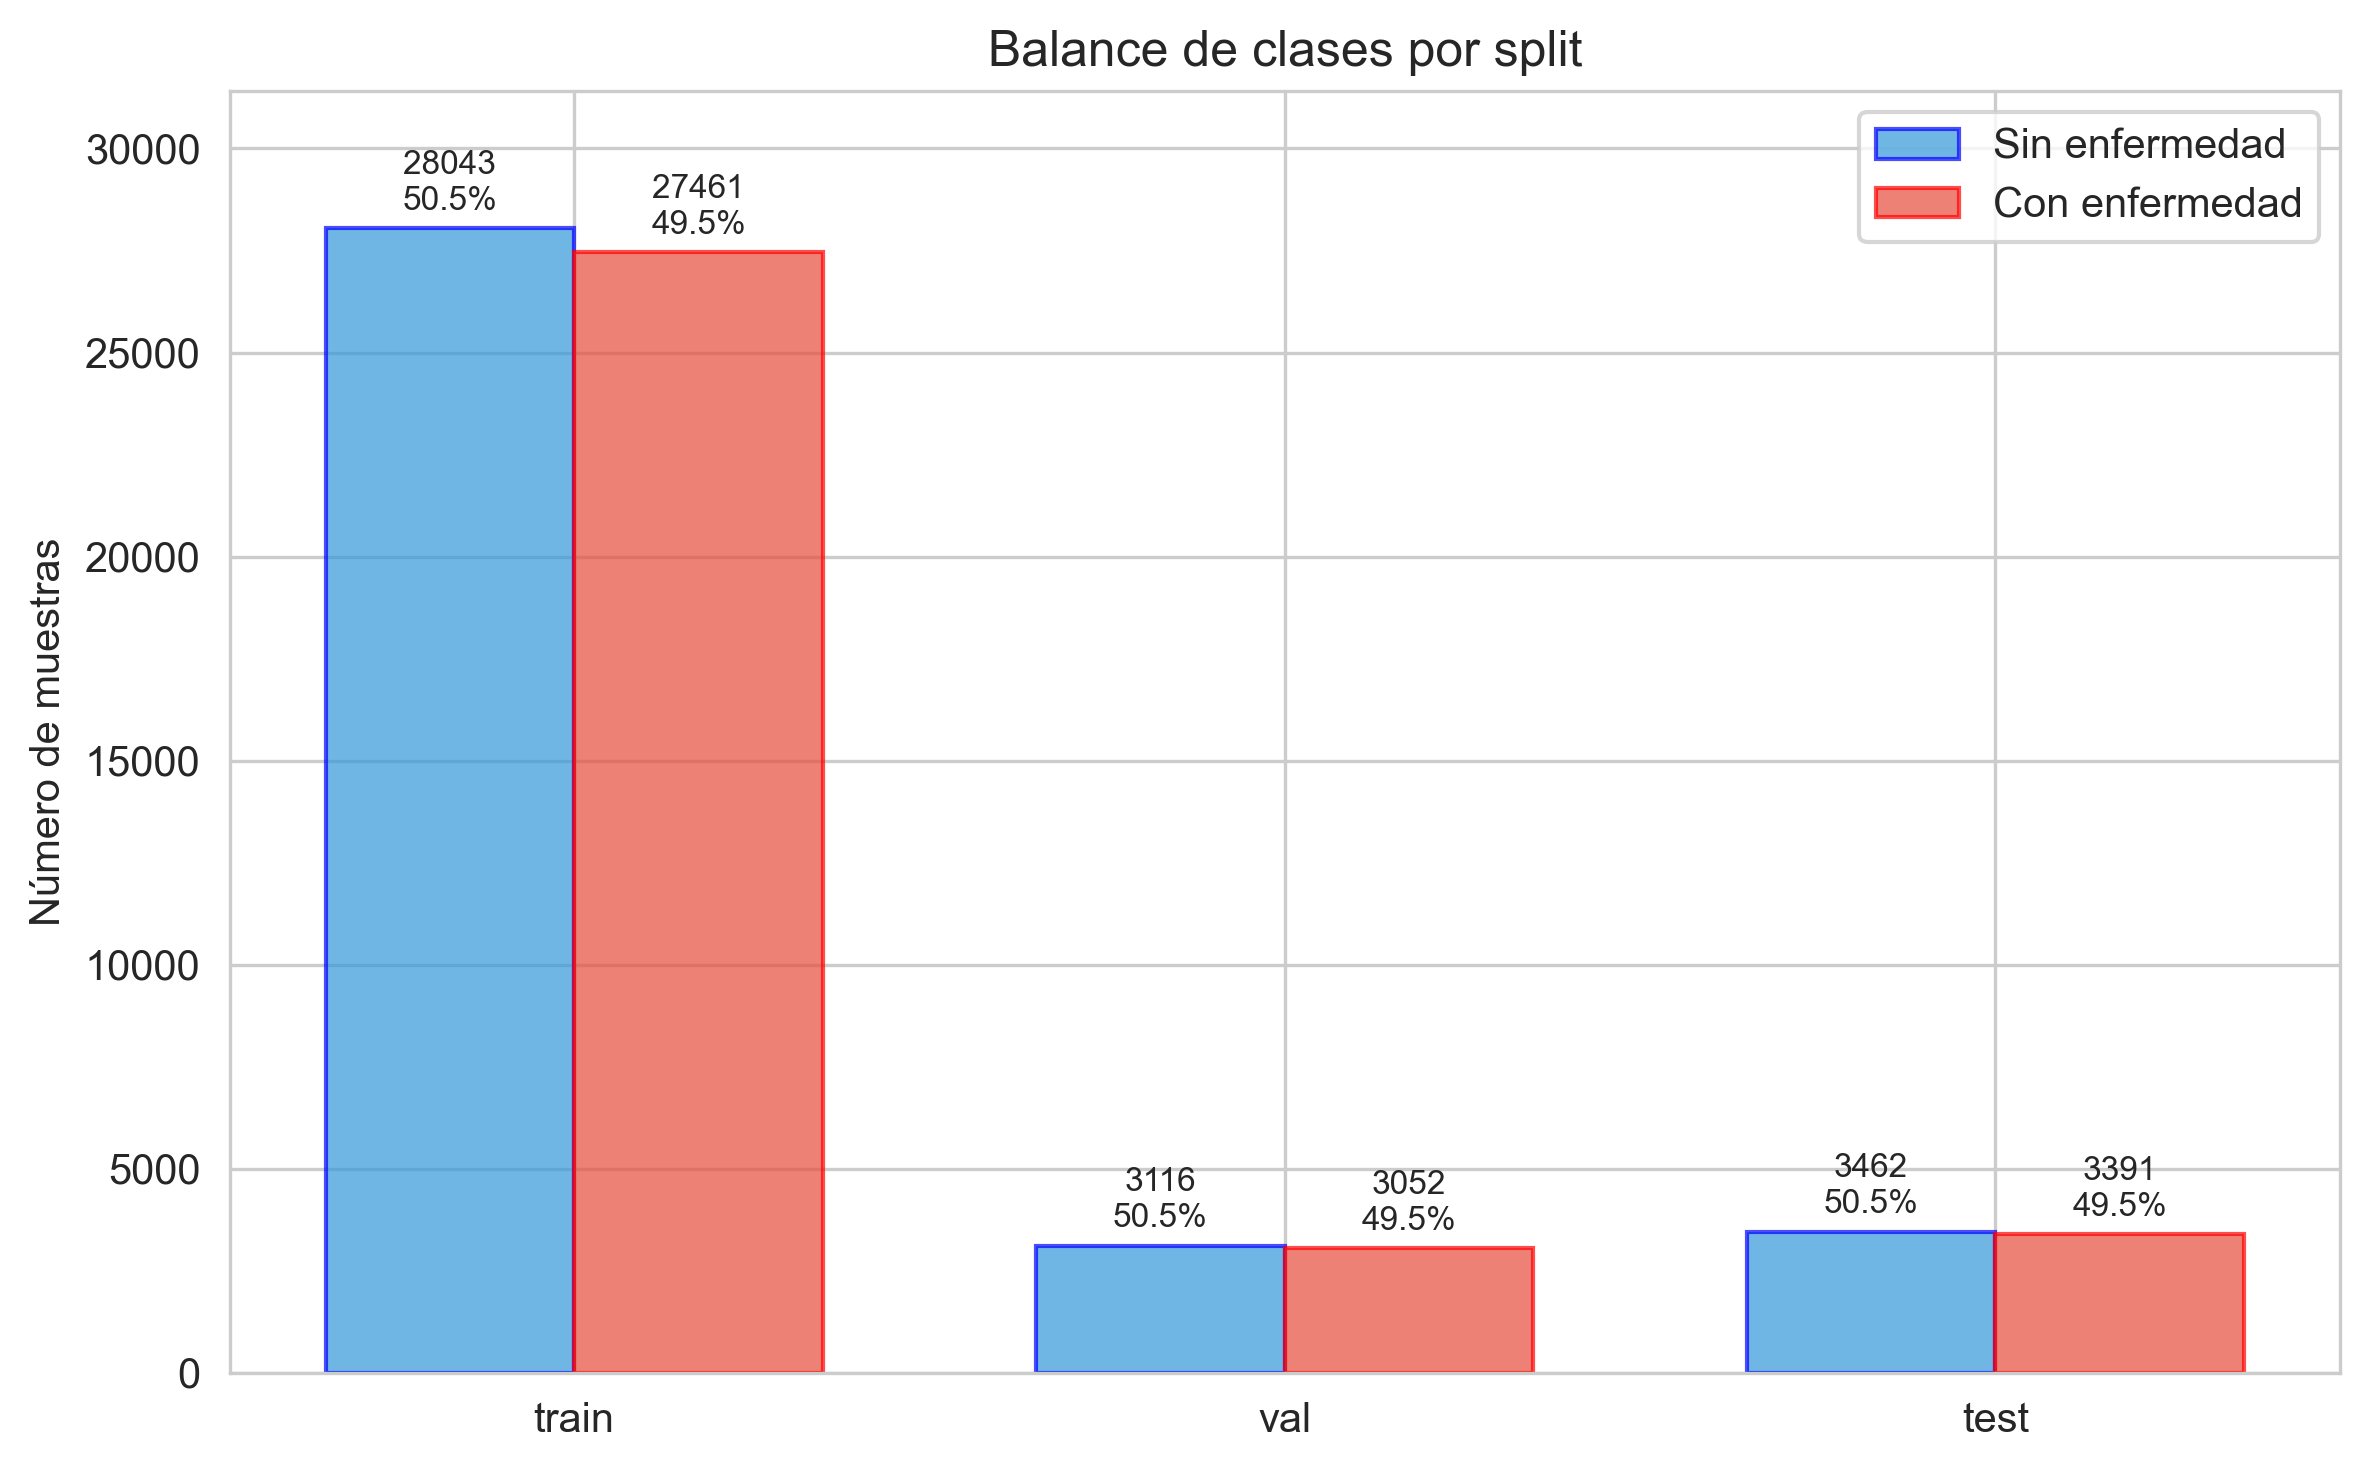

In [6]:
balance_df = (
    data_all.groupby(['split', 'cardio'])
    .size()
    .reset_index(name='count')
)

balance_df['cardio_label'] = balance_df['cardio'].map({0: 'Sin enfermedad', 1: 'Con enfermedad'})

pivot = balance_df.pivot(index='split', columns='cardio_label', values='count').reindex(['train', 'val', 'test'])
pct = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(pivot.index))
width = 0.35

bars0 = ax.bar(x - width / 2, pivot['Sin enfermedad'], width, label='Sin enfermedad', color='#3498db', alpha=0.7, edgecolor='blue')
bars1 = ax.bar(x + width / 2, pivot['Con enfermedad'], width, label='Con enfermedad', color='#e74c3c', alpha=0.7, edgecolor='red')

y_max = pivot.values.max()
ax.set_ylim(0, y_max * 1.12)

for bars, col in zip([bars0, bars1], ['Sin enfermedad', 'Con enfermedad']):
    for i, bar in enumerate(bars):
        count = pivot.iloc[i][col]
        perc = pct.iloc[i][col] * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.01,
            f'{int(count)}\n{perc:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_title('Balance de clases por split')
ax.set_xlabel('')
ax.set_ylabel('Número de muestras')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend()
plt.tight_layout()
plt.show()



## 5. Análisis de Variables

### 5.1 Análisis de Variable Númericas

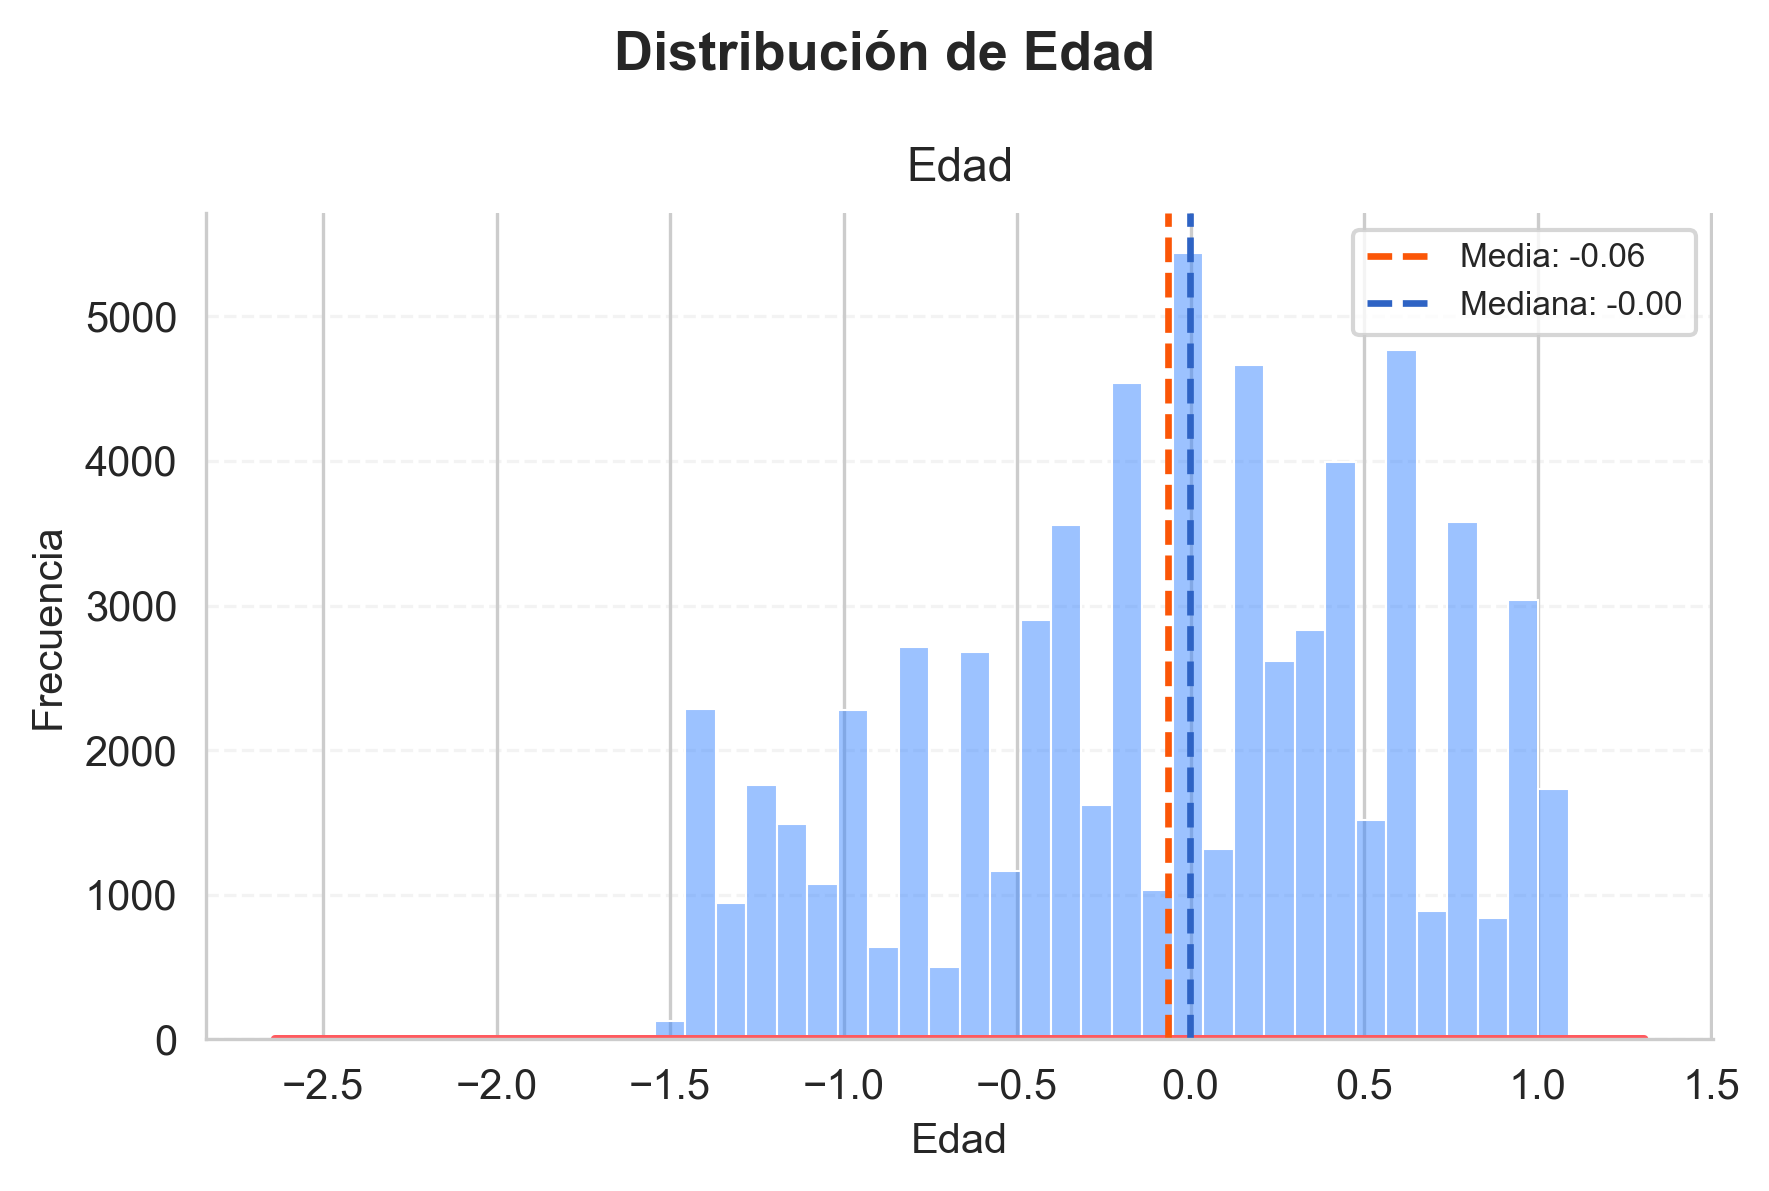

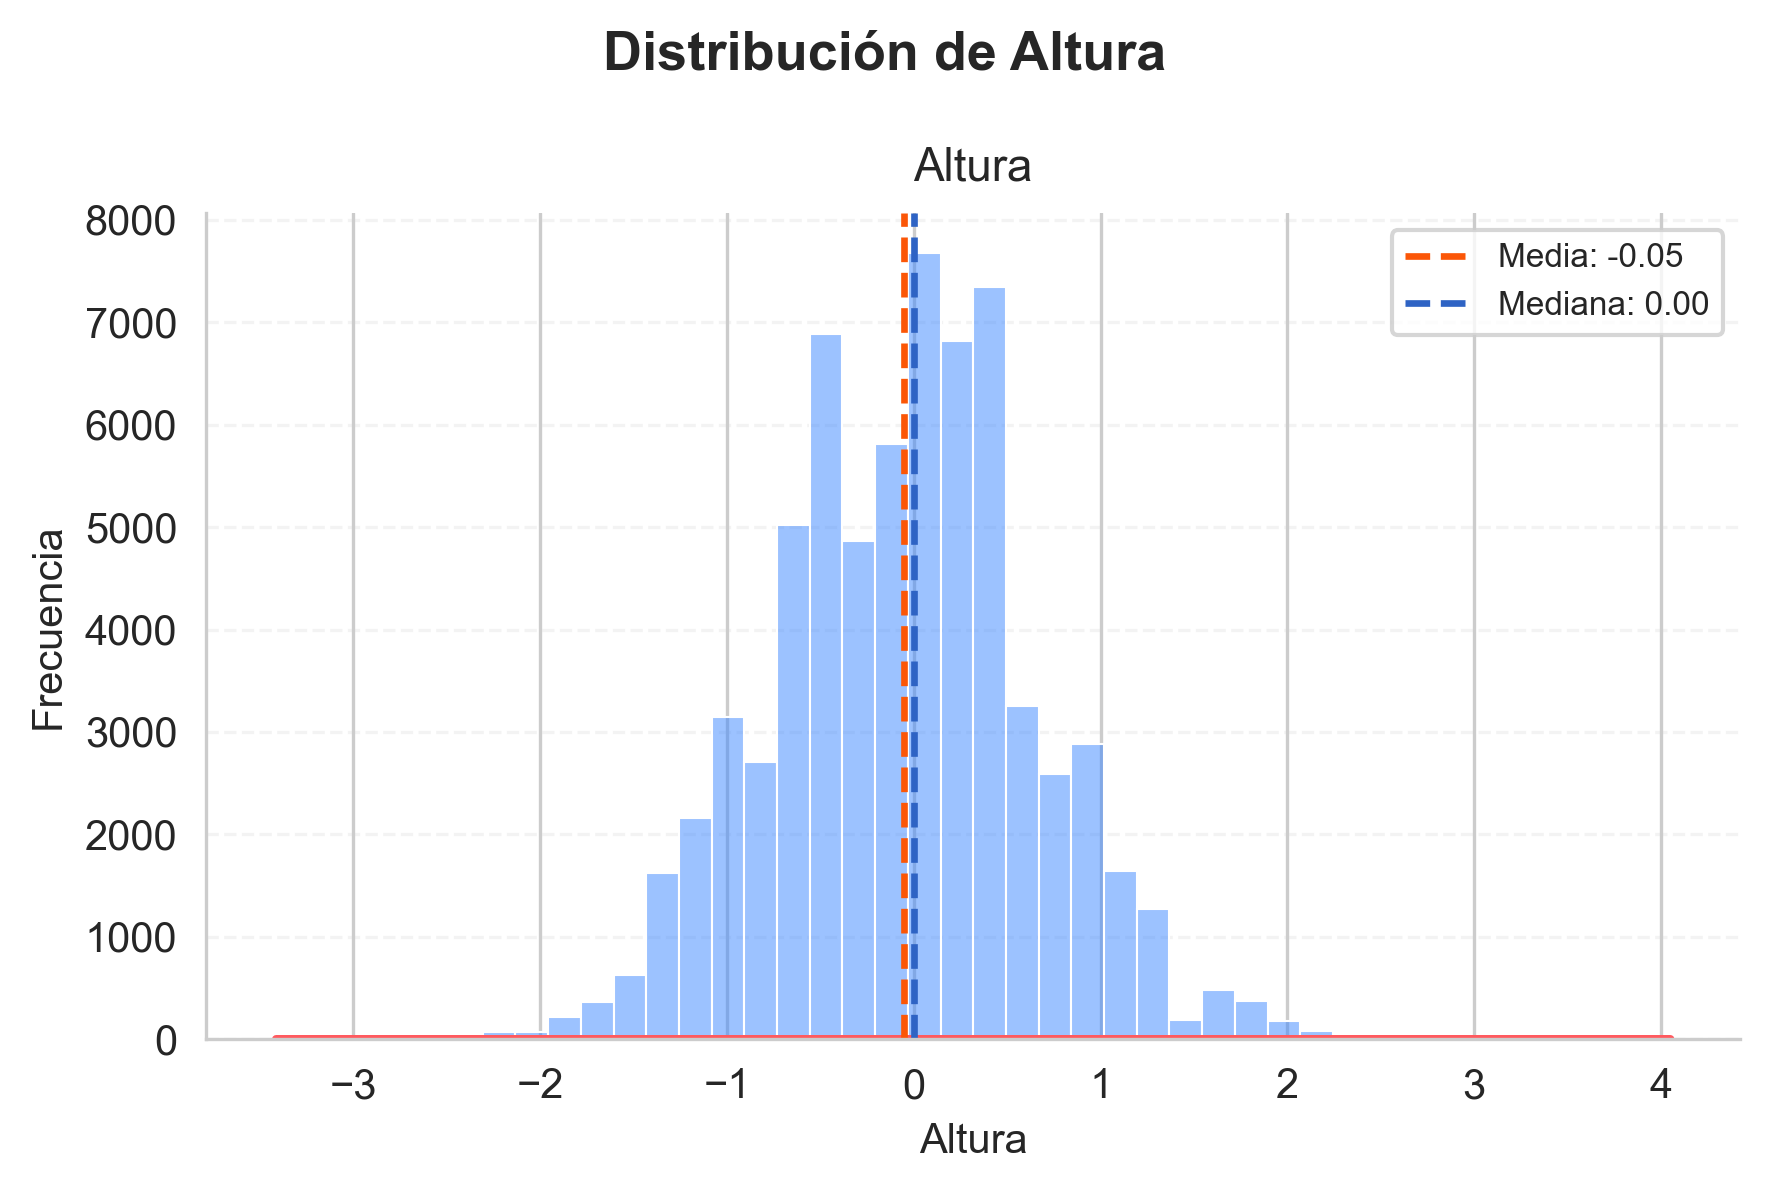

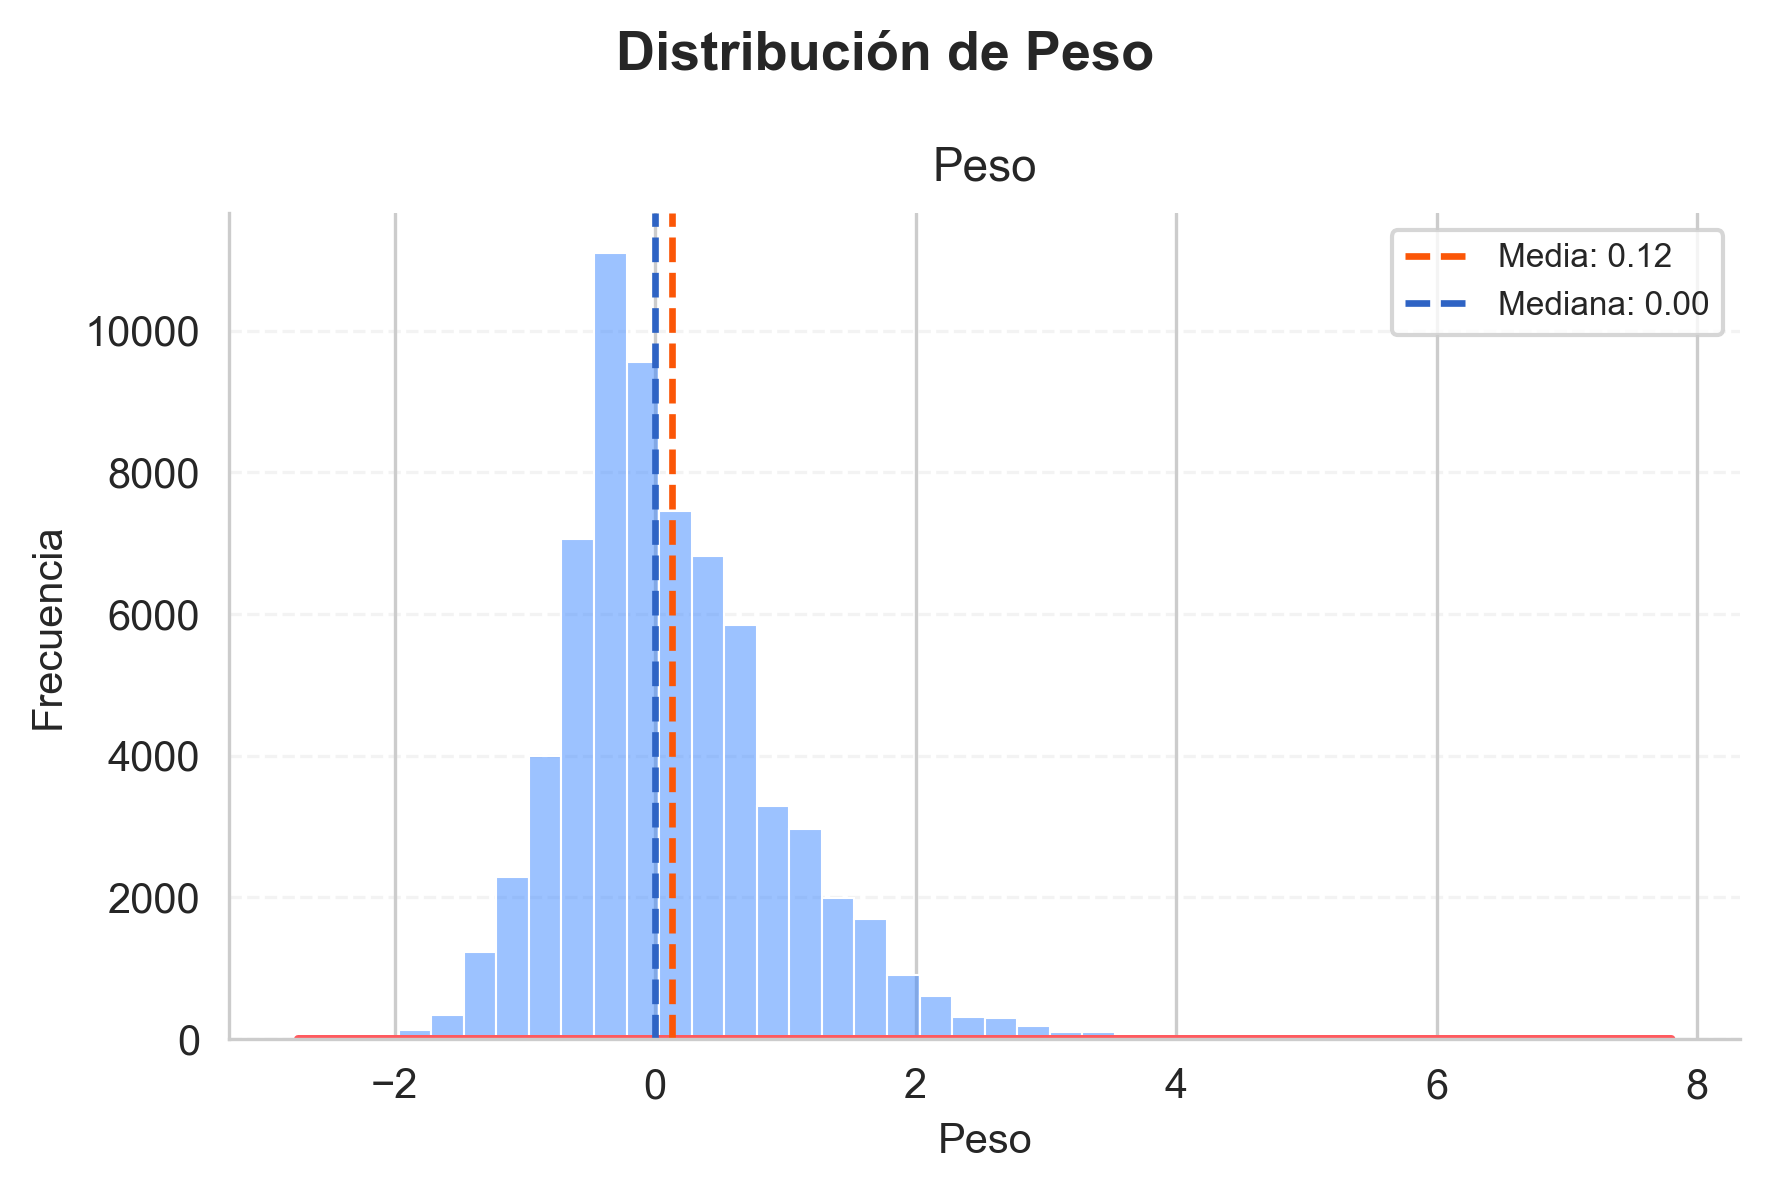

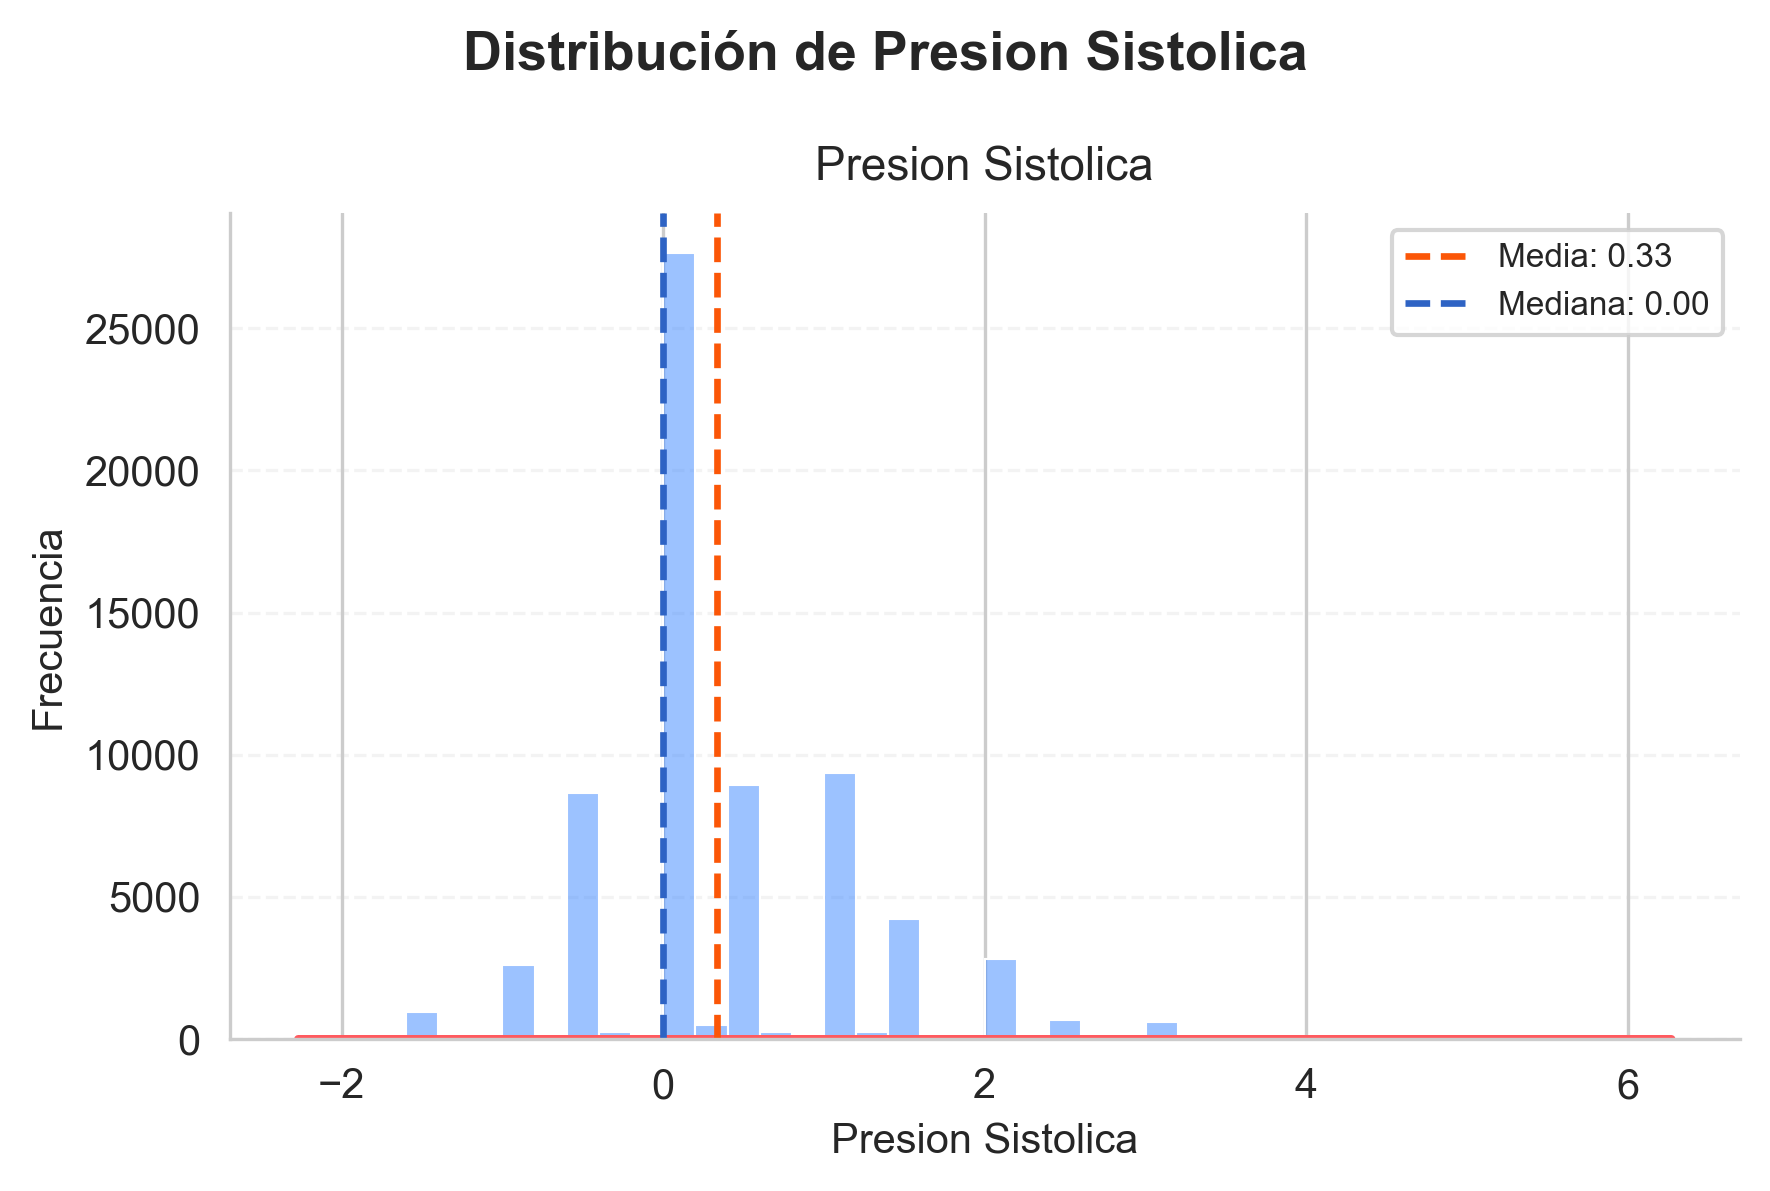

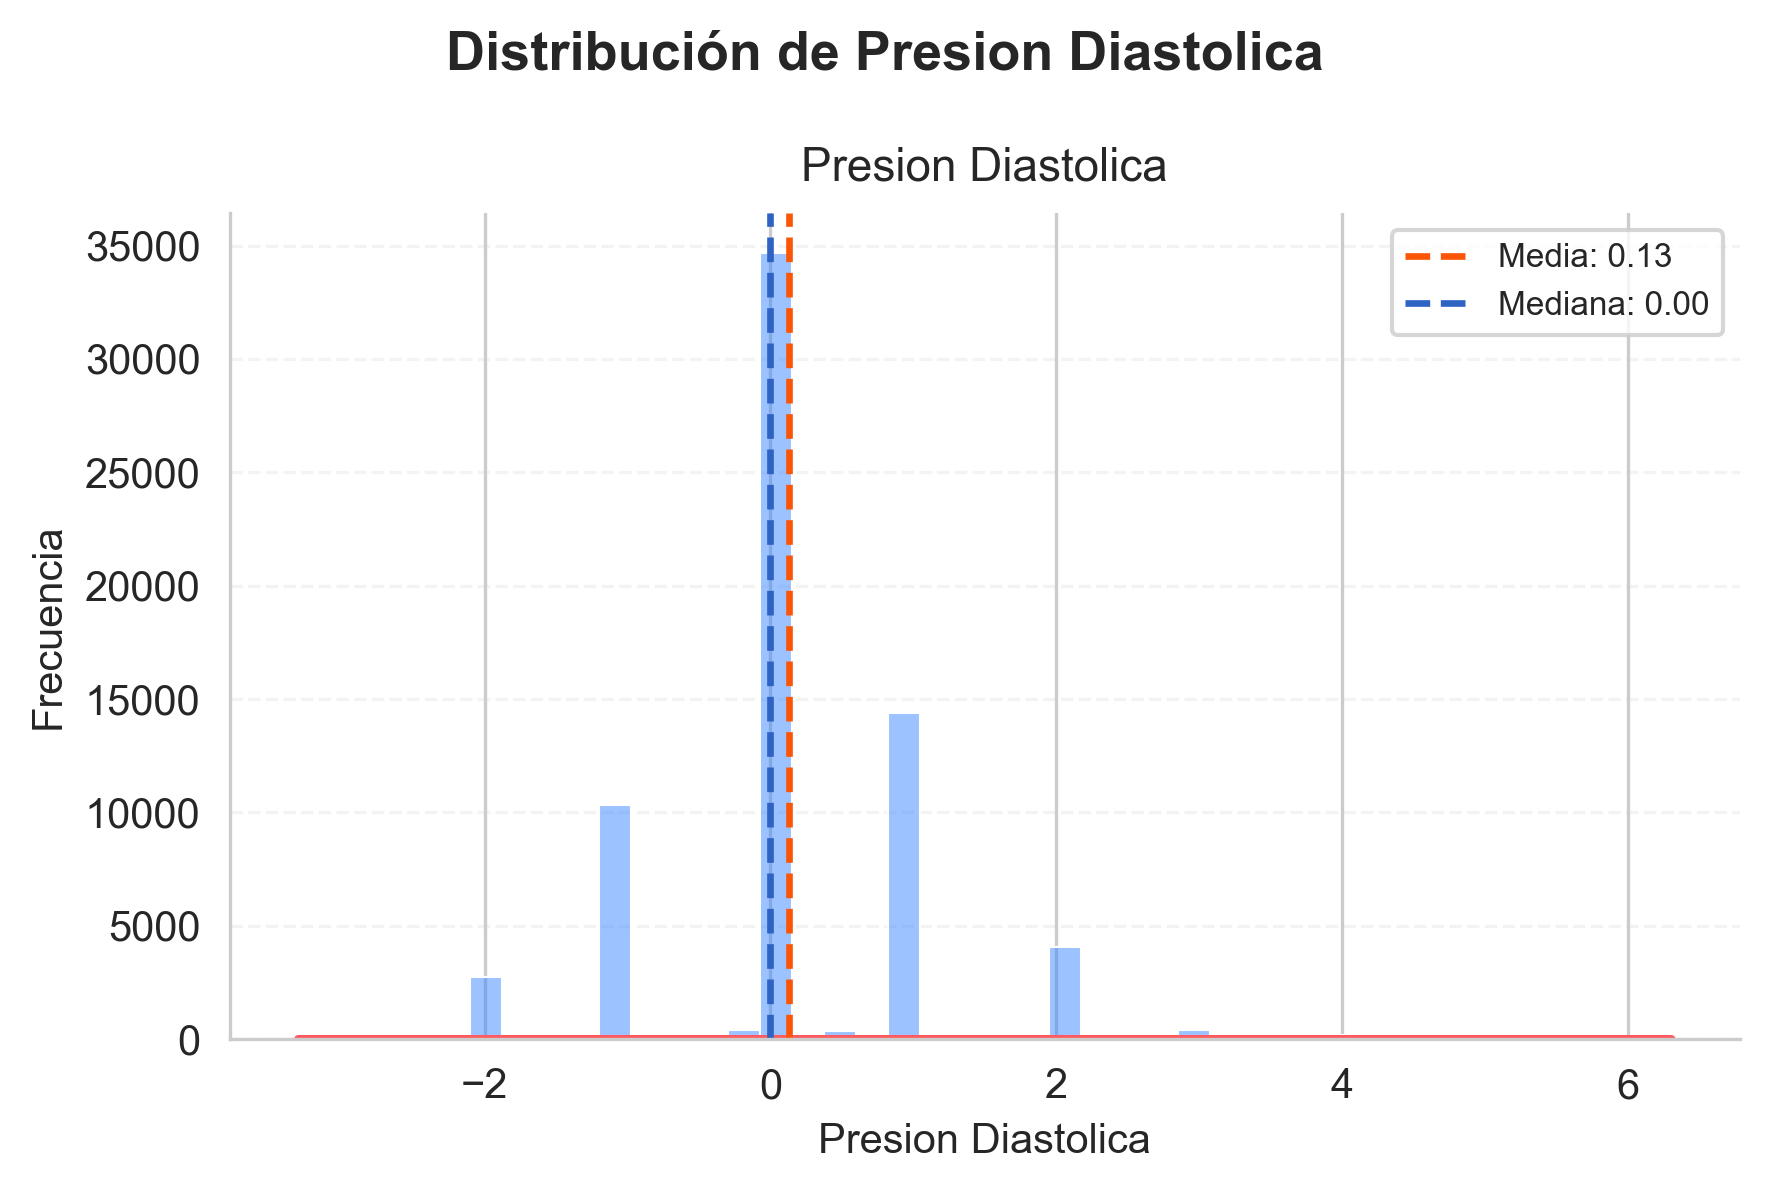

In [7]:
# Variables numéricas de interés (todas las numéricas disponibles)
variables_num = {
    'age': 'Edad',
    'height': 'Altura',
    'weight': 'Peso',
    'ap_hi': 'Presion Sistolica',
    'ap_lo': 'Presion Diastolica'
}

for col, nombre in variables_num.items():
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.histplot(
        data_all[col],
        bins=40,
        stat='count',
        color='#3A86FF',
        alpha=0.5,
        edgecolor='white',
        linewidth=0.5,
        ax=ax
    )
    sns.kdeplot(
        data_all[col],
        color='#FF5A5F',
        linewidth=2.0,
        ax=ax
    )

    # Estadísticas
    media = data_all[col].mean()
    mediana = data_all[col].median()
    ax.axvline(media, color='#FB5607', linestyle='--', linewidth=1.6, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color="#2E63C4", linestyle='--', linewidth=1.6, label=f'Mediana: {mediana:.2f}')

    ax.set_title(nombre, fontsize=11, pad=8)
    ax.set_xlabel(nombre, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.22, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(f'Distribución de {nombre}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 5.2. Análisis de Variables Categóricas

In [ ]:
variables_cat = {
    'gender': {0: 'Mujer', 1: 'Hombre'},
    'cholesterol': {0: 'Normal', 1: 'Elevado', 2: 'Muy elevado'},
    'gluc': {0: 'Normal', 1: 'Elevado', 2: 'Muy elevado'},
    'smoke': {0: 'No fumador', 1: 'Fumador'},
    'alco': {0: 'No consume', 1: 'Consume'},
    'active': {-1: 'No activo', 0: 'Activo'}
}

nombres_vars = {
    'gender': 'Sexo',
    'cholesterol': 'Nivel de Colesterol',
    'gluc': 'Nivel de Glucosa',
    'smoke': 'Tabaquismo',
    'alco': 'Consumo de Alcohol',
    'active': 'Actividad Física'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (var, etiquetas) in enumerate(variables_cat.items()):
    ax = axes[idx]

    tabla = pd.crosstab(data_all[var].round().astype(int), data_all['cardio'])
    tabla = tabla.reindex(etiquetas.keys(), fill_value=0)

    x_pos = np.arange(len(etiquetas))
    width = 0.35

    ax.bar(x_pos - width / 2, tabla[0], width, label='Sin enfermedad',
           color='#3498db', alpha=0.7, edgecolor='blue')
    ax.bar(x_pos + width / 2, tabla[1], width, label='Con enfermedad',
           color='#e74c3c', alpha=0.7, edgecolor='red')

    ax.set_title(nombres_vars[var], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Número de Pacientes', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(list(etiquetas.values()), rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3. Análisis de Variables Transformadas

In [ ]:
feature_candidates = [
    'pulse_pressure',
    'map',
    'imc',
    'edad_años',
    'imc_categoria',
    'edad_grupo',
    'hipertension_nivel',
    'lifestyle_score',
    'risk_factor_count',
    'imc_edad_interaction',
    'presion_imc_interaction',
    'colesterol_glucosa_interaction',
    'edad_squared',
    'imc_squared'
]

selected = [c for c in feature_candidates if c in X_all.columns][:9]

for col in selected:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(data_all[col], kde=True, ax=ax, color='#2c7fb8')
    ax.set_title(col)
    ax.set_xlabel('Valor escalado')
    ax.set_ylabel('Frecuencia')

    ax.spines['bottom'].set_color('#FF5A5F')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.tick_params(axis='x', colors='black')

    plt.tight_layout()
    plt.show()


## 7. Relacion con la variable objetivo

In [ ]:
key_features = [
    c for c in ['pulse_pressure', 'map', 'imc', 'edad_años', 'ap_hi', 'ap_lo', 'lifestyle_score']
    if c in data_all.columns
]
key_features = key_features[:6]

plot_data = data_all.copy()
plot_data['cardio_label'] = plot_data['cardio'].map({0: 'Sin enfermedad', 1: 'Con enfermedad'})

for col in key_features:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(
        data=plot_data,
        x='cardio_label',
        y=col,
        ax=ax,
        palette=['#3498db', '#e74c3c']
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Valor escalado')
    plt.tight_layout()
    plt.show()


## 8. Correlaciones con la variable objetivo

In [ ]:
# Correlación de Spearman con la variable objetivo
corr_with_target = (
    data_all.drop(columns=['split'])
    .corr(method='spearman')['cardio']
    .drop('cardio')
    .sort_values()
)

top_pos = corr_with_target.tail(8)
top_neg = corr_with_target.head(8)
corr_top = pd.concat([top_neg, top_pos])

plt.figure(figsize=(8, 5))
sns.barplot(x=corr_top.values, y=corr_top.index, palette='vlag')
plt.title('Top correlaciones con cardio')
plt.xlabel('Correlacion (Pearson)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index
corr_matrix = data_all[top_features].corr(method='spearman')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación de Spearman')
plt.tight_layout()
plt.show()

## 9. Resumen

- Se trabaja con las salidas transformadas de `build_features.py`, ya escaladas y divididas en train/val/test.
- El balance de clases se mantiene estable por split.
- Las features derivadas muestran distribuciones coherentes y relaciones visibles con la variable objetivo.
- Las correlaciones ayudan a priorizar variables para el modelado y la interpretabilidad.